# LLM Basics

## Agenda
1. LLM and Memory
2. Structured Outputs
3. Tool Calls


## Imports

In [1]:
import sys 

sys.path.insert(0,"../code")

In [2]:
from utils_import import *

/home/vscode/.local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import rich
from pydantic import BaseModel

In [4]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from IPython.display import Image


LangChain has integrations with all the LLM providers. 

OpenAI client supports a `base_url` parameter that can be used to point to other OpenAI compatable services.


In [ ]:
model = ChatOpenAI(
    model=OPENAI_MODEL,
    base_url=OPENAI_BASE_URL,
    api_key=OPENAI_API_KEY,
    max_tokens=512,
)

## Memory 

Large language models don't have external memory and cannot remember user preferences across interactions.

When you interact with OpenAI in the UX, it injects past conversations 

In [6]:
model.invoke("What is my favorite animal?")

AIMessage(content="I don’t know yet! Since we haven't talked about it before, I have no way of knowing.\n\n**Would you like to tell me, or should I try to guess?**", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 210, 'prompt_tokens': 22, 'total_tokens': 232, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 165, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'google/gemma-4-31b', 'system_fingerprint': 'google/gemma-4-31b', 'id': 'chatcmpl-nvzwiribbdovw6gng18v', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e13db-f42e-7e42-b0f2-26d1f0626add-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 22, 'output_tokens': 210, 'total_tokens': 232, 'input_token_details': {}, 'output_token_details': {'reasoning': 165}})

In [7]:
model.invoke([
    SystemMessage(content="You are a helpful assistant that remembers user preferences."),
    HumanMessage(content="My favorite animal is elephants."),
    
])

AIMessage(content="That's a wonderful choice! Elephants are truly incredible animals—known for their intelligence, strong family bonds, and amazing memories.\n\nI've noted that elephants are your favorite animal, so I'll keep that in mind for our future conversations! 🐘", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 181, 'prompt_tokens': 32, 'total_tokens': 213, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 123, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'google/gemma-4-31b', 'system_fingerprint': 'google/gemma-4-31b', 'id': 'chatcmpl-31h5fn7nlz2zhedoi99ml', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e13dc-2c88-7652-8bd3-0f3ec53f849c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 32, 'output_tokens': 181, 'total_tokens': 213, 'input_token_details': {}, 'output_token_de

In [8]:
model.invoke([
    SystemMessage(content="You are a helpful assistant that remembers user preferences."),
    HumanMessage(content="My favorite animal is elephants."),
    AIMessage(content="yes , elephants are cool"),
    HumanMessage(content="what is my favorite animal?"),
    
])


AIMessage(content='Your favorite animal is elephants!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 53, 'total_tokens': 118, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 55, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'google/gemma-4-31b', 'system_fingerprint': 'google/gemma-4-31b', 'id': 'chatcmpl-gxv6km1rzeiqp904qom9q', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e13dc-5da4-7f52-abb7-142802cab447-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 53, 'output_tokens': 65, 'total_tokens': 118, 'input_token_details': {}, 'output_token_details': {'reasoning': 55}})

The above example shows how `memory` can be stored in the conversation history.

## Structured Outputs

Structured Outputs is a feature that ensures the LLM will always generate responses that adhere to a specified supplied JSON Schema, so you don't need to worry about the model omitting a required key, or hallucinating an invalid enum value.

Some benefits of Structured Outputs include:

- Reliable type-safety: No need to validate or retry incorrectly formatted responses
- Explicit refusals: Safety-based model refusals are now programmatically detectable
- Simpler prompting: No need for strongly worded prompts to achieve consistent formatting

[OpenAI Reference](https://platform.openai.com/docs/guides/structured-outputs#page-top)

In [9]:
with tracer.start_as_current_span("output_unstructued"):
    res = model.invoke("Tell me some facts about elephants.")
rich.print(res)


AIMessage(
    content='Elephants are some of the most fascinating creatures on Earth. Here are several facts about them, 
categorized by their biology, intelligence, and social behavior.\n\n### 1. The Three Different Species\nMany people
think there are only two types of elephants, but scientists generally recognize three:\n*   **African Bush 
Elephant:** The largest of all; found in the savannas of sub-Saharan Africa.\n*   **African Forest Elephant:** 
Smaller and found in the rainforests of Central and West Africa.\n*   **Asian Elephant:** Found across Southeast 
Asia; they have smaller ears and a more rounded back than their African cousins.\n\n### 2. The Incredible 
Trunk\nThe trunk is one of the most versatile organs in the animal kingdom. It is a fusion of the nose and the 
upper lip.\n*   **Muscular Power:** An elephant\'s trunk has roughly **40,000 muscles** (humans have about 600 in 
their entire body!).\n*   **Precision & Strength:** They can use it to knock down an entire tree or delicately pick
up a single blade of grass.\n*   **Multipurpose tool:** They use it for smelling, breathing, trumpeting, drinking 
water, and communicating with other elephants.\n\n### 3. Intelligence and Memory\nThe phrase "an elephant never 
forgets" is based in scientific truth.\n*   **Brain Power:** Elephants have the largest brain of any land 
animal.\n*   **Long-term Memory:** Matriarchs (the female leaders) can remember the location of water holes and 
food sources across hundreds of miles, even if they haven\'t visited them for decades.\n*   **Self-Awareness:** 
Elephants are one of the few species capable of recognizing themselves in a mirror, which is a sign of high 
cognitive function.\n\n### 4. Social Structure and Emotion\nElephants are deeply emotional and social animals.\n*  
**Matriarchal Society:** Herds are led by the oldest and wisest female (the matriarch). Males generally leave the 
herd when they reach puberty.\n*   **Empathy:** They are known to show empathy toward other species. They have also
been observed "mourning" their dead, staying with a deceased family member for days and gently touching the bones 
with their trunks.\n*   **Communication:** Besides trumpeting, elephants communicate via 
**infrasound**—low-frequency sounds that travel through the ground and can be heard by other elephants several 
miles away.\n\n### 5. Diet and Ecology\nElephants are "ecosystem engineers," meaning they shape the environment 
around them.\n*   **Eating Habits:** They are herbivores and spend up to **16 hours a day eating**. An adult 
elephant can consume up to 300 pounds (136 kg) of food in one day.\n*   **Seed Dispersal:** Because they eat so 
many fruits and plants and travel long distances, their dung spreads seeds across the landscape, helping forests 
grow.\n*   **Water Needs:** They can drink over 50 gallons of water a day.\n\n### 6. A Few "Quick Facts"\n*   
**Skin Care:** Their skin is very thick (up to an inch), but it\'s sensitive to sunburn. That’s why they throw mud 
and sand on their backs—it acts as a natural sunscreen.\n*   **Tusks:** Tusks are actually elongated incisor teeth 
that grow throughout the elephant\'s life.\n*   **Sleep:** In the wild, elephants only sleep for about 2 to 4 hours
a day.',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 1122,
            'prompt_tokens': 23,
            'total_tokens': 1145,
            'completion_tokens_details': {
                'accepted_prediction_tokens': None,
                'audio_tokens': None,
                'reasoning_tokens': 369,
                'rejected_prediction_tokens': None
            },
            'prompt_tokens_details': None
        },
        'model_provider': 'openai',
        'model_name': 'google/gemma-4-31b',
        'system_fingerprint': 'google/gemma-4-31b',
        'id': 'chatcmpl-oefvq1vpwnakw74t9zvt2n',
        'finish_reason': 'stop',
        'logprobs': No

raw response from gpt.  

Lets now require the model to have the response return a fixed structure

In [10]:
class AnimalInfo(BaseModel):
    name:str
    first_discovered:str
    latin_name: str
    num_species:str

In [11]:
model_with_structured_output = model.with_structured_output(AnimalInfo)


In [12]:
with tracer.start_as_current_span("output_structured"):
    res = model_with_structured_output.invoke("Tell me some facts about elephants.")
rich.print(res)


LengthFinishReasonError: Could not parse response content as the length limit was reached - CompletionUsage(completion_tokens=4073, prompt_tokens=23, total_tokens=4096, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=None, reasoning_tokens=0, rejected_prediction_tokens=None), prompt_tokens_details=None)

![Structured Output Trace](../images/trace_structured_output.jpg)


we can see the generated text is parsed into the AnimalInfo model instance

## Tool Calling

As we saw in the weather example, LLM dont have access to outside information .

In order to bypass this limitation, we can provide `tools` .

A tool is just a python function.

LLM will provide text that matches a function call declaration



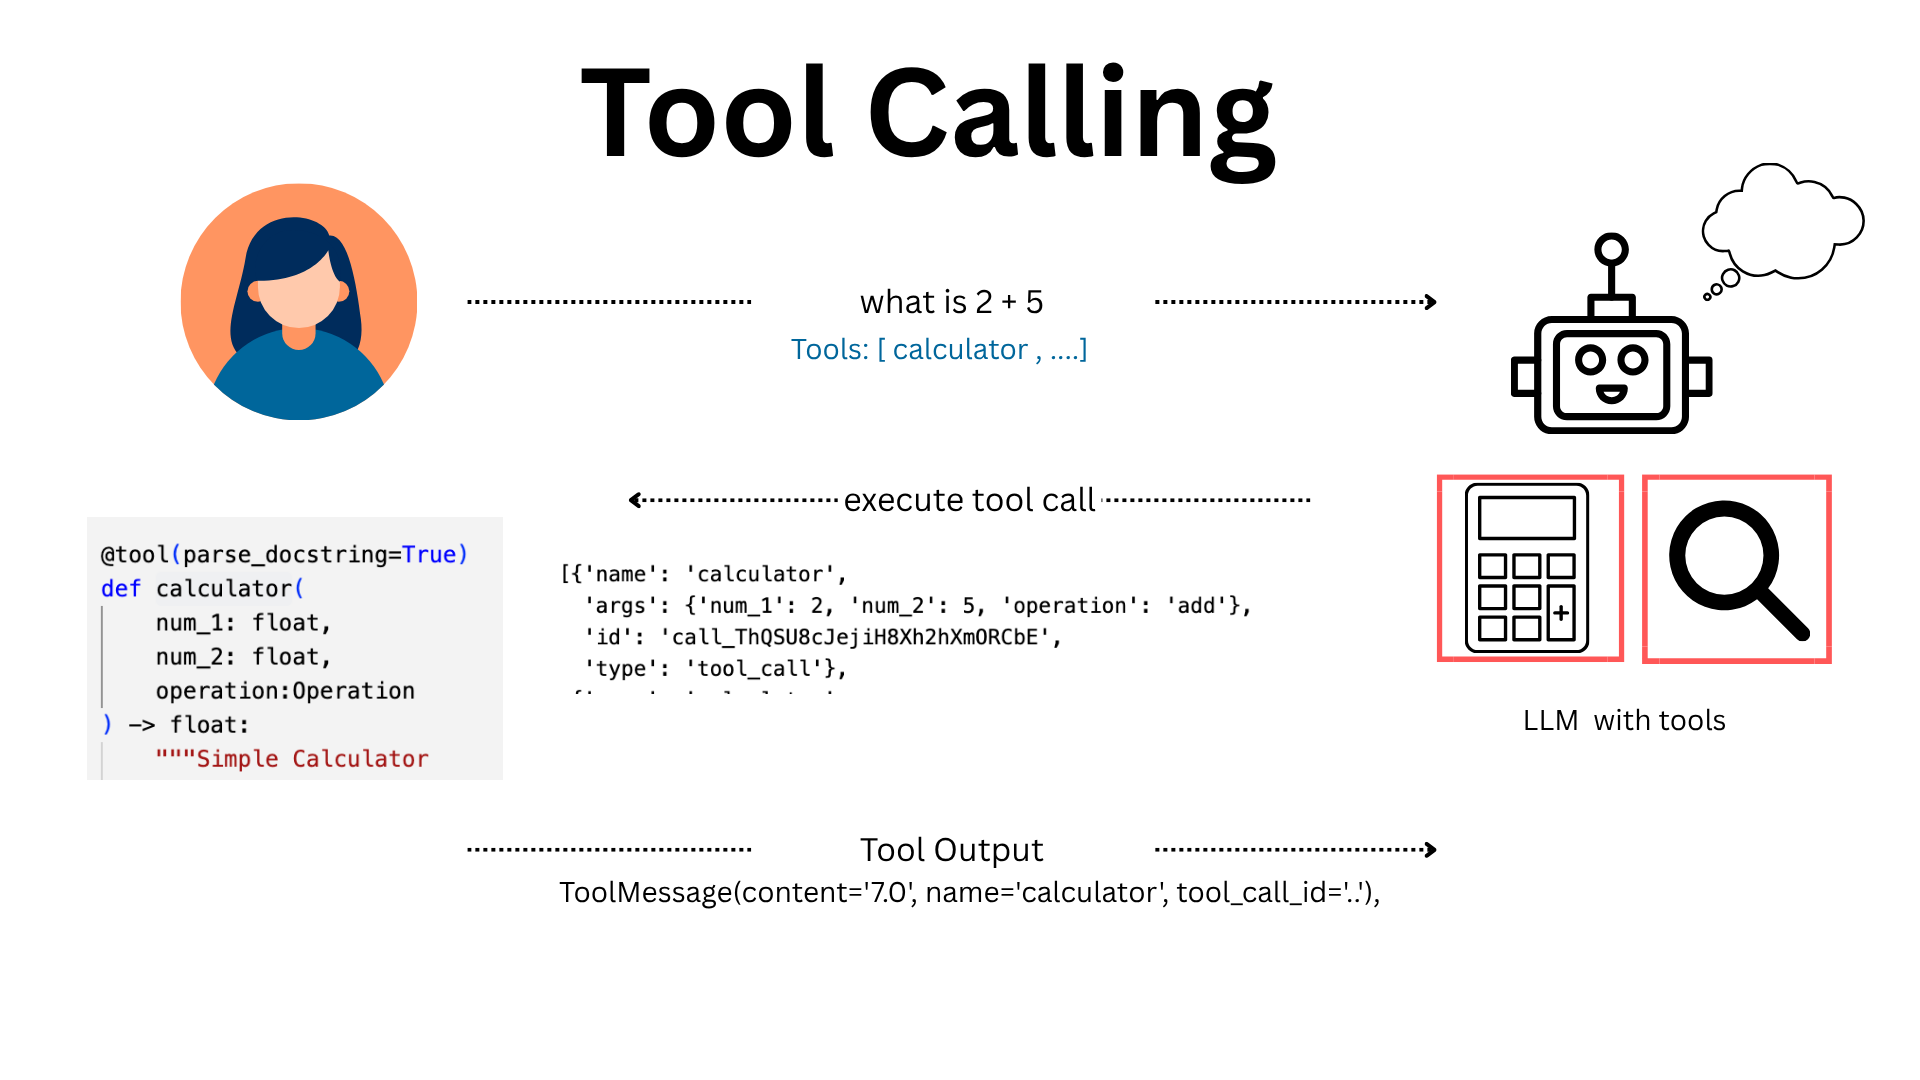

In [ ]:
Image(filename='../images/tool_calling.png', width=800)

In [ ]:
from langchain_core.tools import tool


In [ ]:
@tool
def animal_joke_tool(animal: str) -> str:
    """Return a short, clean joke for turtle/cat/dog (falls back to dog)."""

    JOKES = {
    "turtle": "Why don’t turtles use public Wi-Fi? Too many shell networks.",
    "cat":    "Why did the cat sit on the computer? To keep an eye on the mouse.",
    "dog":    "What do you call a dog that does magic? A labracadabrador.",
    }
    return JOKES.get((animal or "").lower().strip(), JOKES["dog"])





assign the tools to the model

In [ ]:
tool_model = model.bind_tools([animal_joke_tool])


In [ ]:
animal = "turtle"
messages = [
    SystemMessage(content="You are a concise jokester."),
    HumanMessage(content=f"Tell me a short, clean joke about {animal}."),
]


Model would generate a ToolCallMessage like below:

In [ ]:
with tracer.start_as_current_span("tool_calling_example"):
    ai_msg_with_tool_call = tool_model.invoke(messages)

    print("Message generated from our llm call")
    rich.print(ai_msg_with_tool_call)



Message generated from our llm call


AIMessage(
    content='',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 18,
            'prompt_tokens': 74,
            'total_tokens': 92,
            'completion_tokens_details': {
                'accepted_prediction_tokens': 0,
                'audio_tokens': 0,
                'reasoning_tokens': 0,
                'rejected_prediction_tokens': 0
            },
            'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}
        },
        'model_provider': 'openai',
        'model_name': 'gpt-4o-mini-2024-07-18',
        'system_fingerprint': 'fp_560af6e559',
        'id': 'chatcmpl-CZd1JTV4WQI3MAEJnSqpAUxtbAmdI',
        'service_tier': 'default',
        'finish_reason': 'tool_calls',
        'logprobs': None
    },
    id='lc_run--45448d2c-cb4f-4785-8423-e2fc50176db0-0',
    tool_calls=[
        {
            'name': 'animal_joke_tool',
            'args': {'animal': 'turtle'},
            'id': 'call_YFXd6UaG1JTu6NCNKiymFuXj',
            'type': 'tool_call'
        }
    ],
    usage_metadata={
        'input_tokens': 74,
        'output_tokens': 18,
        'total_tokens': 92,
        'input_token_details': {'audio': 0, 'cache_read': 0},
        'output_token_details': {'audio': 0, 'reasoning': 0}
    }
)

under `tool_calls`, we see a request to call `animal_joke_tool`

In [ ]:
tool_call_input = ai_msg_with_tool_call.tool_calls[0]
tool_call_input

{'name': 'animal_joke_tool',
 'args': {'animal': 'turtle'},
 'id': 'call_YFXd6UaG1JTu6NCNKiymFuXj',
 'type': 'tool_call'}

let us manually call the joke tool now

In [ ]:
tool_result_output = animal_joke_tool.invoke(tool_call_input['args'])

print("tool output result")
print(tool_result_output)

tool output result
Why don’t turtles use public Wi-Fi? Too many shell networks.


now in order to pass the tool result back to the model, we need to create a ToolMessage

In [ ]:
from langchain_core.messages import ToolMessage

tool_result_message = ToolMessage(
    content=tool_result_output,
    tool_call_id=tool_call_input['id']
)

In [ ]:
messages + [ai_msg_with_tool_call ,tool_result_message ]

[SystemMessage(content='You are a concise jokester.', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='Tell me a short, clean joke about turtle.', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 74, 'total_tokens': 92, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatcmpl-CZd1JTV4WQI3MAEJnSqpAUxtbAmdI', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--45448d2c-cb4f-4785-8423-e2fc50176db0-0', tool_calls=[{'name': 'animal_joke_tool', 'args': {'animal': 'turtle'}, 'id': 'call_YFXd6UaG1JTu6NCNKiymFuXj', 'type': 'tool_call'}], usag

In [ ]:
tool_model.invoke(
        messages + [ai_msg_with_tool_call ,tool_result_message ]
)

AIMessage(content='Why don’t turtles use public Wi-Fi? Too many shell networks!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 116, 'total_tokens': 131, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatcmpl-CZd3cNg5N58ybQ8dLFh22Y5CZK3V2', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--1c321ce8-c5a9-4c2d-a60b-82a7fdf059b8-0', usage_metadata={'input_tokens': 116, 'output_tokens': 15, 'total_tokens': 131, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

We are responsible for passing the tool output back to the model.  

We can technically pass non tool output as long as we match the tool call id

In [ ]:
tool_result_message_fake = ToolMessage(
    content="Turtles are too cool for jokes",
    tool_call_id=tool_call_input['id']
)

In [ ]:
tool_model.invoke(
        messages + [ai_msg_with_tool_call ,tool_result_message_fake ]
)

AIMessage(content="Turtles are too cool for jokes! But I'll give it a shell again if you want.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 109, 'total_tokens': 129, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatcmpl-CZd9u6hMDkTW7zAZD9J1Noxih3IOr', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--9873c97f-d535-4533-b2d5-742cb8d1fbf5-0', usage_metadata={'input_tokens': 109, 'output_tokens': 20, 'total_tokens': 129, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})